# TRIAL TO SEE IF THE ANNOTATIONS ARE COMPATIBLE WITH YOLO

In [ ]:
!pip install torch torchvision torchaudio
!pip install opencv-python
!pip install matplotlib
!pip install seaborn
!pip install scipy
!pip install tqdm
!pip install pyyaml
!pip install ultralytics

In [1]:
import cv2
img = cv2.imread("/home/martina/codi2/3year/synthesisII/yolo_dataset/images/train/HM20240814213507.jpg")
print(img.shape)  # (height, width, channels)

(640, 480, 3)


fliplr=0.5 (Horizontal Flip):

- Not needed if babies are always lying in the same orientation (e.g., always head on the left).

- Useful if babies are randomly positioned (e.g., sometimes head-left, sometimes head-right).

flipud=0.5 (Vertical Flip):

- Almost never needed (babies are rarely upside-down in incubators).



In [4]:
from ultralytics import YOLO

# Load a pre-trained YOLOv5 model
model = YOLO('yolov5s.pt')  # or 'yolov5m.pt', 'yolov5l.pt', 'yolov5x.pt'

# Train with mixed orientations
model.train(
    data="dataset.yaml",
    imgsz=640,
    batch=8,
    epochs=2,
    augment=True,  # Keeps fliplr=0.5 (good for random left/right flips)
    rect=True,     # Optimizes padding for mixed portrait/landscape
    device="cpu"
)



PRO TIP 💡 Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

New https://pypi.org/project/ultralytics/8.3.95 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.86 🚀 Python-3.10.12 torch-2.6.0+cu124 CPU (11th Gen Intel Core(TM) i5-1135G7 2.40GHz)
engine/trainer: task=detect, mode=train, model=yolov5s.pt, data=dataset.yaml, epochs=2, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=cpu, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=True, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False

train: Scanning /home/martina/codi2/3year/synthesisII/yolo_dataset/labels/train... 3 images, 1 backgrounds, 0 corrupt: 100%|██████████| 3/3 [00:00<00:00, 113.40it/s]

train: New cache created: /home/martina/codi2/3year/synthesisII/yolo_dataset/labels/train.cache
WARNING ⚠️ 'rect=True' is incompatible with DataLoader shuffle, setting shuffle=False



val: Scanning /home/martina/codi2/3year/synthesisII/yolo_dataset/labels/val... 3 images, 0 backgrounds, 0 corrupt: 100%|██████████| 3/3 [00:00<00:00, 289.46it/s]

val: New cache created: /home/martina/codi2/3year/synthesisII/yolo_dataset/labels/val.cache


...

                   all          3         22      0.818      0.111      0.156      0.125



2 epochs completed in 0.005 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 18.5MB
Optimizer stripped from runs/detect/train/weights/best.pt, 18.5MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.86 🚀 Python-3.10.12 torch-2.6.0+cu124 CPU (11th Gen Intel Core(TM) i5-1135G7 2.40GHz)
YOLOv5s summary (fused): 84 layers, 9,113,858 parameters, 0 gradients, 23.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:04<00:00,  4.29s/it]


                   all          3         22      0.833      0.163      0.168      0.137
                  baby          3          3          1       0.98      0.995      0.819
                  core          3          3          1          0     0.0086    0.00258
                   arm          3          4          0          0    0.00481   0.000962
                   leg          3          6          1          0          0          0
                  hand          1          1          1          0          0          0
                  foot          3          5          1          0          0          0
Speed: 5.3ms preprocess, 1337.2ms inference, 0.0ms loss, 71.6ms postprocess per image
Results saved to runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f6fb5e07070>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
     


image 1/1 /home/martina/codi2/3year/synthesisII/diferent/HM20240815055937.jpeg: 640x480 4 arms, 268.9ms
Speed: 7.8ms preprocess, 268.9ms inference, 5.0ms postprocess per image at shape (1, 3, 640, 480)


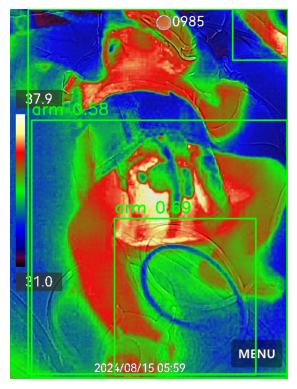

In [5]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
%matplotlib inline

# Predict on a new image
image_path = '/home/martina/codi2/3year/synthesisII/diferent/HM20240815055937.jpeg'

# Load model
model = YOLO('/home/martina/codi2/3year/synthesisII/runs/detect/train/weights/best.pt')

# Predict (use full-size image)
results = model(image_path, imgsz=640)  # Match original resolution (or omit imgsz)
result = results[0]

# Load original image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Draw bounding boxes (now correctly scaled)
for box in result.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])  # Already in original image coordinates
    cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    label = f"{result.names[int(box.cls[0])]} {float(box.conf[0]):.2f}"
    cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

# Plot
plt.imshow(image)
plt.axis('off')
plt.show()